In [14]:
import scanpy as sc
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib
import matplotlib.pyplot as plt
from umap import UMAP
import sklearn
import seaborn as sns
# from COSMOS import cosmos
# from COSMOS.pyWNN import pyWNN 
import h5py
import warnings
warnings.filterwarnings('ignore')
random_seed = 20

/Users/assadullahimran/developer/SpatialGlue_asad/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
import h5py

# Open the file
file_path = 'MOB/ATAC_RNA_Seq_MouseBrain_RNA_ATAC.h5'
f = h5py.File(file_path, 'r')

print(f"Contents of {file_path}:\n")

# Loop through all the keys (components) in the file
for key in f.keys():
    dataset = f[key]
    
    # Print the name, shape (dimensions), and data type of each component
    print(f"Name: {key}")
    print(f"  Shape: {dataset.shape}")
    print(f"  Data Type: {dataset.dtype}")
    print("-" * 30)

# Always close the file when you're done inspecting it
f.close()


Contents of MOB/ATAC_RNA_Seq_MouseBrain_RNA_ATAC.h5:

Name: Cell
  Shape: (9215,)
  Data Type: object
------------------------------
Name: Gene
  Shape: (3000,)
  Data Type: object
------------------------------
Name: LayerName
  Shape: (9215,)
  Data Type: object
------------------------------
Name: Pos
  Shape: (9215, 2)
  Data Type: float64
------------------------------
Name: X_ATAC
  Shape: (9215, 50)
  Data Type: float64
------------------------------
Name: X_RNA
  Shape: (9215, 3000)
  Data Type: float64
------------------------------


In [10]:
f = h5py.File('MOB/ATAC_RNA_Seq_MouseBrain_RNA_ATAC.h5', 'r')

print("First 5 Genes:")
# We use .decode('utf-8') because strings are often saved as bytes in h5 files
print([g.decode('utf-8') for g in f['Gene'][:5]]) 

print("\nFirst 5 Spatial Coordinates:")
print(f['Pos'][:5])

f.close()


First 5 Genes:
['Ppp1r14c', 'Mthfd1l', 'Gm25694', 'ENSMUSG00000096054', 'Vip']

First 5 Spatial Coordinates:
[[ 0. 91.]
 [82. 91.]
 [81. 91.]
 [80. 91.]
 [79. 91.]]


In [11]:
import h5py
import anndata as ad
import pandas as pd
import numpy as np

# Open the custom HDF5 file
f = h5py.File('MOB/ATAC_RNA_Seq_MouseBrain_RNA_ATAC.h5', 'r')

# Extract metadata (convert byte strings to regular strings)
cell_names = [c.decode('utf-8') for c in f['Cell'][:]]
gene_names = [g.decode('utf-8') for g in f['Gene'][:]]
layer_names = [l.decode('utf-8') for l in f['LayerName'][:]]
spatial_coords = f['Pos'][:]

# 1. Create RNA AnnData object
adata_rna = ad.AnnData(X=f['X_RNA'][:])
adata_rna.obs_names = cell_names
adata_rna.var_names = gene_names
adata_rna.obs['Layertype'] = layer_names
adata_rna.obsm['spatial'] = spatial_coords

# 2. Create ATAC AnnData object
# Note: ATAC var_names are just PC/LSI dimensions (0 to 49) since it's already reduced
adata_atac = ad.AnnData(X=f['X_ATAC'][:])
adata_atac.obs_names = cell_names
adata_atac.obs['Layertype'] = layer_names
adata_atac.obsm['spatial'] = spatial_coords

# Close the file when done
f.close()

print("RNA Object:", adata_rna)
print("ATAC Object:", adata_atac)


RNA Object: AnnData object with n_obs × n_vars = 9215 × 3000
    obs: 'Layertype'
    obsm: 'spatial'
ATAC Object: AnnData object with n_obs × n_vars = 9215 × 50
    obs: 'Layertype'
    obsm: 'spatial'


In [12]:
data_mat = h5py.File('./MOB/ATAC_RNA_Seq_MouseBrain_RNA_ATAC.h5', 'r')
df_data_RNA = np.array(data_mat['X_RNA']).astype('float64')     # gene count matrix
df_data_ATAC= np.array(data_mat['X_ATAC']).astype('float64')  # protein count matrix
loc = np.array(data_mat['Pos']).astype('float64') 
LayerName = list(data_mat['LayerName'])
LayerName = [item.decode("utf-8") for item in LayerName]

adata1 = sc.AnnData(df_data_RNA, dtype="float64")
adata1.obsm['spatial'] = np.array(loc)
adata1.obs['LayerName'] = LayerName
adata1.obs['x_pos'] = np.array(loc)[:,0]
adata1.obs['y_pos'] = np.array(loc)[:,1]

adata2 = sc.AnnData(df_data_ATAC, dtype="float64")
adata2.obsm['spatial'] = np.array(loc)
adata2.obs['LayerName'] = LayerName
adata2.obs['x_pos'] = np.array(loc)[:,0]
adata2.obs['y_pos'] = np.array(loc)[:,1]

/Users/assadullahimran/developer/SpatialGlue_asad/.venv/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/Users/assadullahimran/developer/SpatialGlue_asad/.venv/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)


(np.float64(-4.95),
 np.float64(103.95),
 np.float64(-2.8500000000000005),
 np.float64(103.85))

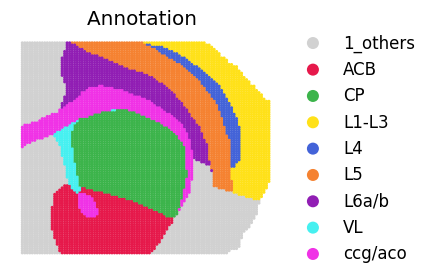

In [15]:
adata_new = adata1.copy()
adata_new.obs["LayerName"]=adata_new.obs["LayerName"].astype('category')


matplotlib.rcParams['font.size'] = 12.0
fig, axes = plt.subplots(1, 1, figsize=(3.5,3))
sz = 20
plot_color=['#D1D1D1','#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', \
            '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#ffd8b1', '#800000', '#aaffc3', '#808000', '#000075', '#000000', '#808080', '#ffffff', '#fffac8']

domains="LayerName"
num_celltype=len(adata_new.obs[domains].unique())
adata_new.uns[domains+"_colors"]=list(plot_color[:num_celltype])
titles = 'Annotation ' 
ax=sc.pl.scatter(adata_new,alpha=1,x="x_pos",y="y_pos",color=domains,title=titles ,color_map=plot_color,show=False,size=sz,ax = axes)
ax.axis('off')